In [1]:
import numpy as np
import pandas as pd

def generate_64_matrix():
    # 1. Define the Genetic Bases (4^3)
    bases = ['U', 'C', 'A', 'G']
    codons = [a+b+c for a in bases for b in bases for c in bases]
    
    # 2. Define the I-Ching Binary (2^6)
    # We represent 0 as Yin (broken) and 1 as Yang (solid)
    hexagrams = [format(i, '06b') for i in range(64)]
    
    # 3. Create the Unified Data Structure
    df = pd.DataFrame({
        'Index': range(64),
        'Codon': codons,
        'Hexagram_Binary': hexagrams
    })
    
    # 4. Assign 'Magnetic Potential' (A simulated N52 B-field effect)
    # We use a sine-wave projection across the W-axis
    df['Potential_W'] = np.sin(df['Index'] * (np.pi / 32)).round(4)
    
    # 5. Define the 'Null Points' (Stop Codons)
    stop_codons = ['UAA', 'UAG', 'UGA']
    df['State'] = df['Codon'].apply(lambda x: 'NULL' if x in stop_codons else 'CONDUCTIVE')
    
    return df

# Initialize the Loom
loom_data = generate_64_matrix()

# Display the first 'wirey' lines of the mapping
print("--- 64-Bit Potential Mapping: DNA vs I-Ching ---")
print(loom_data.head(10))

# Filter for High-Potential 'Start' states (AUG)
start_state = loom_data[loom_data['Codon'] == 'AUG']
print("\n--- Initializing Start Vector (AUG) ---")
print(start_state)

--- 64-Bit Potential Mapping: DNA vs I-Ching ---
   Index Codon Hexagram_Binary  Potential_W       State
0      0   UUU          000000       0.0000  CONDUCTIVE
1      1   UUC          000001       0.0980  CONDUCTIVE
2      2   UUA          000010       0.1951  CONDUCTIVE
3      3   UUG          000011       0.2903  CONDUCTIVE
4      4   UCU          000100       0.3827  CONDUCTIVE
5      5   UCC          000101       0.4714  CONDUCTIVE
6      6   UCA          000110       0.5556  CONDUCTIVE
7      7   UCG          000111       0.6344  CONDUCTIVE
8      8   UAU          001000       0.7071  CONDUCTIVE
9      9   UAC          001001       0.7730  CONDUCTIVE

--- Initializing Start Vector (AUG) ---
    Index Codon Hexagram_Binary  Potential_W       State
35     35   AUG          100011      -0.2903  CONDUCTIVE


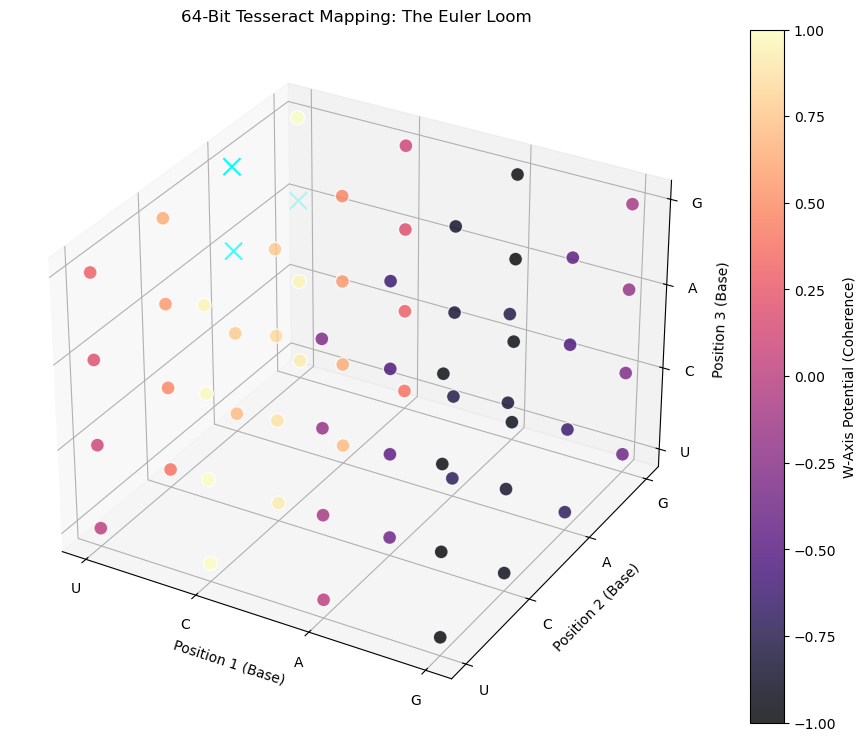

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_64_loom(df):
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    # Map Bases to numeric coordinates for the 4x4x4 cube
    base_map = {'U': 0, 'C': 1, 'A': 2, 'G': 3}
    
    # Extract coordinates from the Codon string
    x = df['Codon'].apply(lambda c: base_map[c[0]])
    y = df['Codon'].apply(lambda c: base_map[c[1]])
    z = df['Codon'].apply(lambda c: base_map[c[2]])
    
    # Use Potential_W for the color mapping (The W-Dimension intensity)
    colors = df['Potential_W']
    
    # Scatter plot: CONDUCTIVE states as spheres, NULL as 'x' markers
    conductive = df[df['State'] == 'CONDUCTIVE']
    null_points = df[df['State'] == 'NULL']
    
    # Plotting Conductive states
    p = ax.scatter(x[conductive.index], y[conductive.index], z[conductive.index], 
                   c=colors[conductive.index], cmap='magma', s=100, edgecolors='w', alpha=0.8)
    
    # Plotting Null/Stop states (The holes in the lattice)
    ax.scatter(x[null_points.index], y[null_points.index], z[null_points.index], 
               color='cyan', marker='x', s=150, label='Null Point (Stop)')

    # Labeling the axes as the Codon Positions
    ax.set_xlabel('Position 1 (Base)')
    ax.set_ylabel('Position 2 (Base)')
    ax.set_zlabel('Position 3 (Base)')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['U', 'C', 'A', 'G'])
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(['U', 'C', 'A', 'G'])
    ax.set_zticks([0, 1, 2, 3])
    ax.set_zticklabels(['U', 'C', 'A', 'G'])
    
    fig.colorbar(p, ax=ax, label='W-Axis Potential (Coherence)')
    plt.title('64-Bit Tesseract Mapping: The Euler Loom')
    plt.show()

# Execute the visualization
plot_64_loom(loom_data)

In [2]:
import os
print(f"Your Forge is located at: {os.getcwd()}")

Your Forge is located at: C:\Users\mkmdk\Sorted\Matter_Manifestation_Device
